## Прогнозирование стоимости жилой недвижимости

### Цель проекта

Разработать ML-модель для прогнозирования ориентировочной цены жилого объекта по информации из объявления. 

In [26]:
import pandas as pd
import numpy as np

df = pd.read_csv('data.csv')

print('Размер:', df.shape)
display(df.head(3))

Размер: (377185, 18)


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"


In [27]:
audit = (
    pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
        'unique': df.nunique(dropna=True)
    })
    .sort_values(['missing_pct', 'unique'], ascending=[False, False])
)

display(audit)

duplicates_count = df.duplicated().sum()

print(f'Полных дубликатов: {duplicates_count:,}')
print(f'Доля полных дубликатов: {duplicates_count / len(df):.3%}')

,dtype,missing,missing_pct,unique
private pool,object,373004,98.89,1
mls-id,object,352243,93.39,24907
PrivatePool,object,336874,89.31,2
fireplace,object,274071,72.66,1652
stories,object,150716,39.96,347
baths,object,106338,28.19,229
beds,object,91282,24.20,1184
MlsId,object,66880,17.73,232944
sqft,object,40577,10.76,25405
status,object,39918,10.58,159


Полных дубликатов: 50
Доля полных дубликатов: 0.013%


## Первичная оценка и удаление дубликатов

На этапе первичного аудита выявлены полные дубликаты строк. Они не несут
дополнительной информации для обучения, поэтому удаляются до формирования
целевой переменной и признаков.

Поле `target` содержит цену в текстовом формате. Перед преобразованием его
в число необходимо проверить примеры значений и отделить объявления о продаже
от объявлений об аренде.

In [28]:
# Удаление полных дубликатов.

rows_before_dedup = len(df)

df = df.drop_duplicates().copy()

rows_after_dedup = len(df)
duplicates_removed = rows_before_dedup - rows_after_dedup

print(f'Размер до удаления дубликатов: {rows_before_dedup:,}')
print(f'Удалено полных дубликатов: {duplicates_removed:,}')
print(f'Размер после удаления дубликатов: {df.shape[0]:,} строк, {df.shape[1]} столбцов')

Размер до удаления дубликатов: 377,185
Удалено полных дубликатов: 50
Размер после удаления дубликатов: 377,135 строк, 18 столбцов


In [29]:
# Предварительный анализ целевой переменной и признака статуса объявления.

target_text = (
    df['target']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)

status_text = (
    df['status']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)

target_missing_count = df['target'].isna().sum()
target_monthly_rent_count = target_text.str.contains(
    r'/mo\b',
    regex=True
).sum()

rent_status_count = status_text.str.contains(
    r'\brent\b',
    regex=True
).sum()

print(f'Пропусков в target: {target_missing_count:,}')
print(f'Цен с пометкой /mo: {target_monthly_rent_count:,}')
print(f'Объявлений со статусом аренды: {rent_status_count:,}')

Пропусков в target: 2,480
Цен с пометкой /mo: 398
Объявлений со статусом аренды: 412


In [30]:
# Примеры текстового формата целевой переменной.
RANDOM_STATE=42

sample_size = min(20, df['target'].notna().sum())

print('Примеры значений target:')
display(
    df.loc[df['target'].notna(), ['target', 'status']]
    .sample(n=sample_size, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print('Примеры объявлений, связанных с арендой:')
is_rent_status = status_text.str.contains(
    r'\brent\b',
    regex=True
)

is_monthly_rent = target_text.str.contains(
    r'/mo\b',
    regex=True
)

is_rent = is_rent_status | is_monthly_rent

display(
    df.loc[
        is_rent,
        ['status', 'target']
    ]
    .head(10)
)

Примеры значений target:


,target,status
0,"$69,500",Active
1,"$519,000",for sale
2,"$325,000",for sale
3,"$302,990",Active
4,"$829,000",For sale
5,"$749,888",New construction
6,"$409,999",for sale
7,"$217,580",for sale
8,"$229,000",for sale
9,"$299,000",NaN


Примеры объявлений, связанных с арендой:


,status,target
547,for rent,"$5,500/mo"
609,for rent,"$10,500/mo"
2075,for rent,"$6,390/mo"
3025,for rent,"$1,200/mo"
3645,for rent,"$3,600/mo"
4613,for rent,"$5,500/mo"
5515,for rent,"$1,200/mo"
5873,Apartment for rent,"$1,250"
6837,for rent,"$1,200/mo"
8167,for rent,"$3,250/mo"


В `target` встречаются цены с символом валюты, разделителями тысяч, знаком `+` и без символа `$`, поэтому цена будет извлекаться регулярным преобразованием в числовой формат. В данных также присутствуют объявления об аренде: часть из них определяется по статусу `for rent`, часть — по маркеру `/mo` в цене. Для модели стоимости продажи такие строки будут исключены.

### Очистка целевой переменной

Поле `target` содержит цену в текстовом формате, поэтому его необходимо
преобразовать в числовой тип. В данных также есть объявления об аренде:
они определяются по слову `rent` в статусе или по пометке `/mo` в цене.

Для моделирования стоимости продажи исключаются:

- объявления об аренде;
- строки без распознанной цены;
- цены ниже $1,000.

Объекты с ценой ровно $1,000 сохраняются: в данных они встречаются преимущественно среди foreclosure-объявлений и могут отражать специфический, но реальный сегмент рынка.

In [31]:
# Определение объявлений, относящихся к аренде.

is_rent = (
    status_text.str.contains(r'\brent\b', regex=True)
    | target_text.str.contains(r'/mo\b', regex=True)
)

# Преобразование текстовой цены в число.
# Удаляем символ валюты, разделители тысяч, знак "+" и другие
# нечисловые символы, затем преобразуем результат в число.
# Корректность преобразования дополнительно проверяется по крайним значениям цены.

df['price'] = pd.to_numeric(
    target_text.str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

# Минимальная допустимая цена продажи.
MIN_SALE_PRICE = 1_000

sales_mask = (
    ~is_rent
    & df['price'].notna()
    & df['price'].ge(MIN_SALE_PRICE)
)

sales_df = df.loc[sales_mask].copy()

print(f'Всего объявлений после удаления дубликатов: {len(df):,}')
print(f'Исключено объявлений об аренде: {is_rent.sum():,}')
print(f'Строк без распознанной цены: {df["price"].isna().sum():,}')
print(f'Строк с ценой ниже ${MIN_SALE_PRICE:,}: {(df["price"].lt(MIN_SALE_PRICE)).sum():,}')
print(f'Объявлений о продаже для дальнейшего анализа: {len(sales_df):,}')

display(
    sales_df['price']
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .to_frame('price')
)

Всего объявлений после удаления дубликатов: 377,135
Исключено объявлений об аренде: 412
Строк без распознанной цены: 2,480
Строк с ценой ниже $1,000: 101
Объявлений о продаже для дальнейшего анализа: 374,167


,price
count,3.741670e+05
mean,6.455644e+05
std,1.842441e+06
min,1.000000e+03
1%,7.500000e+03
5%,3.790000e+04
25%,1.879900e+05
50%,3.200000e+05
75%,5.849000e+05
95%,1.950000e+06


In [32]:
# Проверка нижней и верхней границ целевой переменной.
# Экстремальные значения показываются для ручной проверки, но не удаляются:
# дорогая недвижимость представляет реальный сегмент рынка.

display_columns = [
    'price',
    'propertyType',
    'city',
    'state',
    'zipcode',
    'sqft',
    'beds',
    'baths',
    'status'
]

print('Объекты с минимальными значениями цены:')
display(
    sales_df[display_columns]
    .nsmallest(20, columns='price')
)

print('Объекты с максимальными значениями цены:')
display(
    sales_df[display_columns]
    .nlargest(20, columns='price')
)

Объекты с минимальными значениями цены:


,price,propertyType,city,state,zipcode,sqft,beds,baths,status
1357,1000.0,single-family home,Detroit,MI,48206,"2,544 sqft",6 Beds,2 Baths,foreclosure
1682,1000.0,Single Family,Detroit,MI,48219,"1,572 sqft",4,2.0,NaN
2282,1000.0,single-family home,Detroit,MI,48205,"2,048 sqft",4 Beds,2 Baths,foreclosure
2644,1000.0,single-family home,Detroit,MI,48227,"1,827 sqft",4 Beds,2 Baths,foreclosure
2673,1000.0,NaN,Memphis,TN,38106,NaN,NaN,NaN,Active
2923,1000.0,single-family home,Detroit,MI,48205,921 sqft,3 Beds,NaN,foreclosure
3049,1000.0,single-family home,Detroit,MI,48213,"1,386 sqft",3 Beds,2 Baths,foreclosure
3239,1000.0,single-family home,Detroit,MI,48204,"1,984 sqft",4 Beds,2 Baths,foreclosure
3380,1000.0,NaN,Memphis,TN,38108,NaN,NaN,NaN,Active
3616,1000.0,single-family home,Detroit,MI,48234,687 sqft,3 Beds,NaN,foreclosure


Объекты с максимальными значениями цены:


,price,propertyType,city,state,zipcode,sqft,beds,baths,status
132425,195000000.0,Single Family,Los Angeles,CA,90077,--,11,18.0,For sale
143528,165000000.0,single-family home,Beverly Hills,CA,90210,"28,660 sqft",20 Beds,23 Baths,for sale
285993,165000000.0,Single Family,Beverly Hills,CA,90210,"28,660",20,23.0,For sale
110083,150000000.0,single-family home,Los Angeles,CA,90077,NaN,NaN,NaN,for sale
178931,129000000.0,Single Family,Beverly Hills,CA,90210,"43,000",12,23.0,For sale
119862,115000000.0,Single Family,Los Angeles,CA,90077,"12,201",9,10.0,For sale
294206,115000000.0,single-family home,Los Angeles,CA,90077,"12,201 sqft",9 Beds,10 Baths,for sale
54164,110000000.0,single-family home,Beverly Hills,CA,90210,"38,000 sqft",12 Beds,24 Baths,for sale
354264,110000000.0,lot/land,Beverly Hills,CA,90210,741 sqft,NaN,NaN,for sale
151594,98000000.0,Condo,New York,NY,10016,"19,815",11,14,For sale


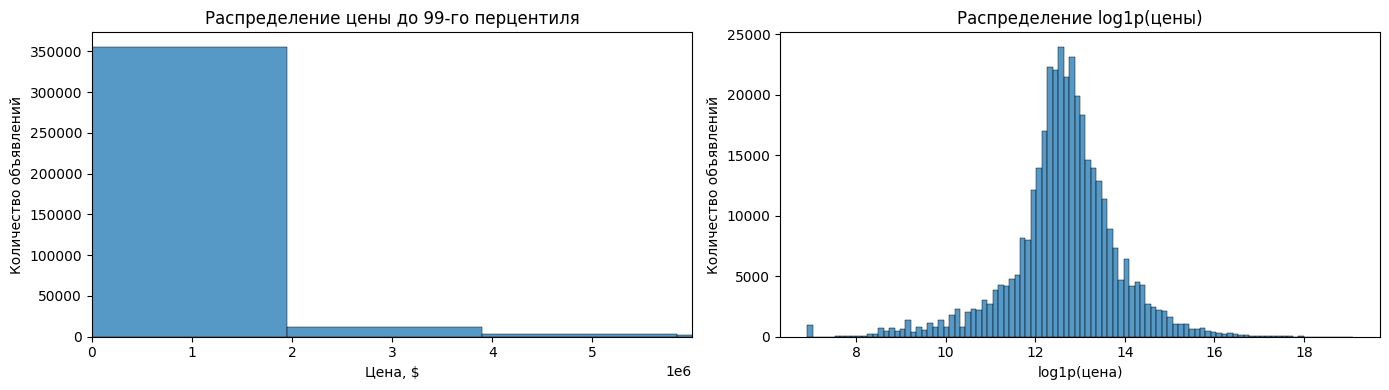

In [33]:
# Анализ распределения целевой переменной.

import matplotlib.pyplot as plt
import seaborn as sns

sales_df['log_price'] = np.log1p(sales_df['price'])

price_p99 = sales_df['price'].quantile(0.99)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

sns.histplot(
    data=sales_df,
    x='price',
    bins=100,
    ax=axes[0]
)
axes[0].set_xlim(0, price_p99)
axes[0].set_title('Распределение цены до 99-го перцентиля')
axes[0].set_xlabel('Цена, $')
axes[0].set_ylabel('Количество объявлений')

sns.histplot(
    data=sales_df,
    x='log_price',
    bins=100,
    ax=axes[1]
)
axes[1].set_title('Распределение log1p(цены)')
axes[1].set_xlabel('log1p(цена)')
axes[1].set_ylabel('Количество объявлений')

plt.tight_layout()
plt.show()

**Вывод.** Распределение цены имеет выраженный правый хвост: медианная цена составляет
$320,000, тогда как средняя — примерно $645,564. Крайне дорогие объекты существенно
влияют на среднее значение и метрики в исходной денежной шкале.

Преобразование `log1p(price)` уменьшает асимметрию распределения и влияние редких
дорогих объектов на обучение. Поэтому модель будет обучаться предсказывать `log_price`,
а итоговые прогнозы и бизнес-метрики будут дополнительно переведены обратно в доллары
с помощью `expm1`.

### Извлечение и очистка числовых признаков

Поля `sqft`, `beds`, `baths` и `stories` хранят числовую информацию в разных
текстовых форматах: с единицами измерения, дополнительными пояснениями,
разделителями тысяч и пропусками.

Для каждого поля используется отдельная функция преобразования. Это позволяет
извлекать значения с учётом смысла столбца: площадь определяется по маркеру
`sqft`, количество спален — по `bed` или `bd`, а количество ванных — по
`bath` или `ba`. Значения, не соответствующие физически допустимым диапазонам,
заменяются на пропуски и будут заполнены медианой только на обучающей выборке.

In [34]:
import re


def normalize_numeric_text(value) -> str:
    """Преобразует значение в нормализованную текстовую строку."""
    if pd.isna(value):
        return ''

    return (
        str(value)
        .strip()
        .lower()
        .replace(',', '')
    )


def parse_sqft(value) -> float:
    """Извлекает площадь объекта в квадратных футах."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:sq\.?\s*ft\.?|sqft)',
        r'(\d+(?:\.\d+)?)\s*$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan


def parse_beds(value) -> float:
    """Извлекает количество спален."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none', 'studio'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:beds?|bd)\b',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan


def parse_baths(value) -> float:
    """Извлекает количество ванных комнат."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:baths?|ba)\b',
        r'(?:bathrooms?\s*:?\s*)(\d+(?:\.\d+)?)',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan


def parse_stories(value) -> float:
    """Извлекает количество этажей."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none', 'studio'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:stories|story|storeys|storey)\b',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan

In [35]:
# Извлечение числовых признаков из текстовых полей.

sales_df['sqft_num'] = sales_df['sqft'].apply(parse_sqft)
sales_df['beds_num'] = sales_df['beds'].apply(parse_beds)
sales_df['baths_num'] = sales_df['baths'].apply(parse_baths)
sales_df['stories_num'] = sales_df['stories'].apply(parse_stories)

numeric_columns = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num'
]


def make_numeric_report(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Формирует сводную таблицу числовых признаков."""
    return pd.DataFrame({
        'missing_pct': frame[columns].isna().mean().mul(100).round(2),
        'min': frame[columns].min(),
        'median': frame[columns].median(),
        'max': frame[columns].max()
    })


print('Сводка до обработки некорректных значений:')
display(make_numeric_report(sales_df, numeric_columns))

Сводка до обработки некорректных значений:


,missing_pct,min,median,max
sqft_num,10.92,0.0,1800.0,795979430.0
beds_num,29.67,0.0,3.0,144.0
baths_num,28.78,0.0,2.5,5000.0
stories_num,43.62,0.0,2.0,1120.0


In [36]:
# Контроль примеров извлечения значений.
# Он подтверждает, что парсеры корректно обрабатывают разные исходные форматы.

parse_check = sales_df[
    ['sqft', 'sqft_num', 'beds', 'beds_num', 'baths', 'baths_num', 'stories', 'stories_num']
].sample(
    n=min(15, len(sales_df)),
    random_state=RANDOM_STATE
)

display(parse_check)

,sqft,sqft_num,beds,beds_num,baths,baths_num,stories,stories_num
63455,629,629.0,1,1.0,1.0,1.0,NaN,NaN
42624,"2,926",2926.0,3,3.0,3.0,3.0,1.0,1.0
67147,"1,289",1289.0,NaN,NaN,NaN,NaN,NaN,NaN
251662,1716,1716.0,3,3.0,2,2.0,NaN,NaN
354373,"1,930",1930.0,Baths,NaN,Sq. Ft.,NaN,NaN,NaN
368370,"1,635 sqft",1635.0,NaN,NaN,NaN,NaN,1.0,1.0
265594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
293289,1380,1380.0,2.0,2.0,2.5,2.5,Townhouse,NaN
254408,"Total interior livable area: 4,699 sqft",4699.0,5 bd,5.0,Bathrooms: 5,5.0,NaN,NaN
306623,"3,512",3512.0,4,4.0,4.0,4.0,2.0,2.0


In [37]:
# Физически допустимые интервалы признаков.
# Значения вне диапазонов считаются ошибками формата и заменяются на NaN.

valid_ranges = {
    'sqft_num': (100, 100_000),
    'beds_num': (0, 60),
    'baths_num': (0.5, 60),
    'stories_num': (1, 50)
}

invalid_counts = {}

for column, (lower_bound, upper_bound) in valid_ranges.items():
    invalid_mask = (
        sales_df[column].notna()
        & ~sales_df[column].between(lower_bound, upper_bound)
    )

    invalid_counts[column] = invalid_mask.sum()
    sales_df.loc[invalid_mask, column] = np.nan

invalid_report = (
    pd.Series(invalid_counts, name='invalid_values')
    .to_frame()
)

print('Количество значений, заменённых на NaN:')
display(invalid_report)

print('Сводка после обработки некорректных значений:')
display(make_numeric_report(sales_df, numeric_columns))

Количество значений, заменённых на NaN:


,invalid_values
sqft_num,12691
beds_num,51
baths_num,18442
stories_num,11569


Сводка после обработки некорректных значений:


,missing_pct,min,median,max
sqft_num,14.31,100.0,1839.0,100000.0
beds_num,29.68,0.0,3.0,53.0
baths_num,33.71,0.5,2.5,60.0
stories_num,46.71,1.0,2.0,50.0


In [38]:
# Проверка минимальных и максимальных допустимых значений после очистки.

inspection_columns = [
    'price',
    'propertyType',
    'city',
    'state',
    'sqft',
    'beds',
    'baths',
    'stories'
]

for column in numeric_columns:
    print(f'\nПроверка границ признака: {column}')

    print('Минимальные значения:')
    display(
        sales_df.loc[
            sales_df[column].notna(),
            [column] + inspection_columns
        ]
        .nsmallest(5, columns=column)
    )

    print('Максимальные значения:')
    display(
        sales_df.loc[
            sales_df[column].notna(),
            [column] + inspection_columns
        ]
        .nlargest(5, columns=column)
    )


Проверка границ признака: sqft_num
Минимальные значения:


,sqft_num,price,propertyType,city,state,sqft,beds,baths,stories
9261,100.0,789000.0,lot/land,Saint Johns,FL,100 sqft,NaN,NaN,NaN
62267,100.0,400000.0,Miscellaneous,Miami,FL,100 sqft,0,NaN,NaN
121653,100.0,700000.0,lot/land,Brooksville,FL,100 sqft,2 Beds,2 Baths,1.0
162864,100.0,20000.0,Single Family Home,Alexandria,VA,100,0,0,1
182169,100.0,401369.0,Single Family,Miami,FL,100 sqft,4,2.0,1.0


Максимальные значения:


,sqft_num,price,propertyType,city,state,sqft,beds,baths,stories
173711,100000.0,410000.0,coop,Brooklyn,NY,"100,000 sqft",NaN,NaN,NaN
63514,99999.0,1600000.0,Multi-Family Home,Madison,TN,99999,NaN,116 / 116 / 116,2.00
350352,99999.0,1600000.0,lot/land,Madison,TN,"99,999 sqft",NaN,NaN,NaN
269404,99876.0,335000.0,coop,Elmhurst,NY,"99,876 sqft",NaN,NaN,1.0
331200,99876.0,660000.0,coop,Elmhurst,NY,"99,876 sqft",2 Beds,2 Baths,5



Проверка границ признака: beds_num
Минимальные значения:


...

,baths_num,price,propertyType,city,state,sqft,beds,baths,stories
307232,60.0,900000.0,multi-family,Detroit,MI,"18,192 sqft",NaN,60 Baths,3.0
110423,55.0,30000000.0,Multi Family,Boston,MA,"30,500",99,55.0,NaN
122038,44.0,20000000.0,multi-family,Boston,MA,"21,210 sqft",78 Beds,44 Baths,NaN
360980,44.0,20000000.0,Multi Family,Boston,MA,"21,210",78,44.0,NaN
363608,44.0,10700000.0,multi-family,Los Angeles,CA,"28,824 sqft",88 Beds,44 Baths,NaN



Проверка границ признака: stories_num
Минимальные значения:


,stories_num,price,propertyType,city,state,sqft,beds,baths,stories
2,1.0,2895000.0,single-family home,Los Angeles,CA,"3,000 sqft",3 Beds,2 Baths,1.0
12,1.0,525000.0,single-family home,Pembroke Pines,FL,"2,839 sqft",4 Beds,3 Baths,1.0
13,1.0,499900.0,Single Family,Eugene,OR,"Total interior livable area: 1,820 sqft",3 bd,Bathrooms: 2,1.0
19,1.0,626000.0,multi-family,Fort Lauderdale,FL,"1,612 sqft",4 Beds,4 Baths,1.0
21,1.0,3500000.0,Single Family,Bend,OR,"Total interior livable area: 5,266 sqft",5 bd,Bathrooms: 5,1.0


Максимальные значения:


,stories_num,price,propertyType,city,state,sqft,beds,baths,stories
74734,50.0,1795000.0,condo,New York,NY,NaN,2 Beds,2 Baths,50
220384,50.0,1050000.0,condo,New York,NY,600 sqft,NaN,NaN,50
366538,50.0,3950000.0,Condo,Miami,FL,"Total interior livable area: 4,030 sqft",3 bd,Bathrooms: 4,50.0
218046,49.0,440000.0,Condo,Miami,FL,"1,203",2,2.0,49.0
278367,49.0,15500000.0,Condo,Sunny Isles Beach,FL,"6,106",4,6.0,49.0


## Вывод по числовым признакам

Текстовые поля площади, количества спален, ванных комнат и этажей преобразованы в числовые признаки с учётом различных форматов: единиц измерения, поясняющего текста и разделителей тысяч.

В исходных данных обнаружены нулевые и экстремально большие значения. Часть из них связана с ошибками или неоднозначным форматом полей, а часть относится к редким крупным объектам. Значения, выходящие за широкие физически допустимые диапазоны, заменены на `NaN`; сами строки не удаляются.

Пропуски и значения `NaN` будут обрабатываться только после разделения данных на train, validation и test, чтобы исключить утечку информации из validation- и test-выборок.

### Тип недвижимости

Исходный признак `propertyType` содержит большое число вариантов написания:
синонимы, разные регистры, архитектурные стили и комбинированные типы
объектов. Для уменьшения количества редких категорий и повышения устойчивости
модели значения агрегируются в укрупнённые группы.

Земельные участки (`land`, `lot/land`) не являются жилыми объектами. Их
распределение цен отличается от распределения стоимости домов, поэтому они
исключаются из выборки в соответствии с целью проекта.

In [39]:
# Нормализация исходного признака propertyType.

property_type = (
    sales_df['propertyType']
    .fillna('missing')
    .astype(str)
    .str.strip()
    .str.lower()
)

print(f'Уникальных исходных значений propertyType: {property_type.nunique():,}')

display(
    property_type
    .value_counts()
    .head(30)
    .to_frame('listings')
)

Уникальных исходных значений propertyType: 1,272


,listings
propertyType,
single-family home,91150
single family,61884
condo,42358
missing,34538
single family home,31724
lot/land,20467
townhouse,18297
land,10928
multi-family,7762


In [40]:
def group_property_type(value: str) -> str:
    """Объединяет исходные типы недвижимости в устойчивые группы."""
    text = str(value).strip().lower()

    if text in {'', 'missing', 'nan', 'none'}:
        return 'missing'

    if re.search(r'\b(?:land|lot)\b', text):
        return 'land'

    if 'condo' in text or 'coop' in text or 'co-op' in text:
        return 'condo_coop'

    if 'town' in text or 'row home' in text:
        return 'townhouse'

    if any(token in text for token in ['multi', 'duplex', 'triplex', 'fourplex']):
        return 'multi_family'

    if 'mobile' in text or 'manufactured' in text:
        return 'mobile_manufactured'

    if 'apartment' in text:
        return 'apartment'

    if any(
        token in text
        for token in [
            'single',
            'detached',
            'ranch',
            'colonial',
            'traditional',
            'contemporary',
            'one story',
            'two story'
        ]
    ):
        return 'single_family'

    return 'other'


sales_df['property_group'] = property_type.apply(group_property_type)

property_summary = (
    sales_df
    .groupby('property_group', dropna=False)
    .agg(
        listings=('price', 'size'),
        median_price=('price', 'median'),
        mean_price=('price', 'mean')
    )
    .sort_values('listings', ascending=False)
)

property_summary['share_pct'] = (
    property_summary['listings']
    .div(len(sales_df))
    .mul(100)
    .round(2)
)

display(property_summary)

,listings,median_price,mean_price,share_pct
property_group,,,,
single_family,206427,334990.0,609663.130056,55.17
condo_coop,55142,369900.0,816657.679573,14.74
missing,34662,310000.0,860066.595407,9.26
land,31458,73000.0,316776.278784,8.41
townhouse,18480,319994.0,576174.586472,4.94
multi_family,12552,599000.0,952953.737014,3.35
other,11077,349000.0,636977.086937,2.96
mobile_manufactured,3560,99500.0,125224.073876,0.95
apartment,809,550000.0,962028.862794,0.22


In [41]:
# Земля исключается до обучения модели.
# Количество рассчитывается по property_group, а не по точному исходному тексту.

land_count = sales_df['property_group'].eq('land').sum()
land_share = land_count / len(sales_df) * 100

sales_df = sales_df.loc[
    sales_df['property_group'].ne('land')
].copy()

print(f'Исключено земельных участков: {land_count:,} ({land_share:.2f}%)')
print(f'Размер выборки после исключения земли: {sales_df.shape[0]:,} строк, {sales_df.shape[1]} столбцов')

Исключено земельных участков: 31,458 (8.41%)
Размер выборки после исключения земли: 342,709 строк, 25 столбцов


В текущем датасете в группу `land` вошли 31,458 объявлений (8.41% выборки), а их медианная цена составила $73,000. Это существенно отличается от медианных цен жилых категорий, поэтому такие объекты исключаются из модели оценки жилой недвижимости.

### Географические признаки

Стоимость недвижимости существенно различается между регионами. Поэтому в
модель будут включены `state`, `city` и `zipcode`. До обучения проверяются
пропуски, количество категорий и распределение объявлений по регионам.

In [42]:
geo_columns = ['state', 'city', 'zipcode']

geo_report = pd.DataFrame({
    'missing': sales_df[geo_columns].isna().sum(),
    'missing_pct': sales_df[geo_columns].isna().mean().mul(100).round(3),
    'unique': sales_df[geo_columns].nunique(dropna=True)
})

display(geo_report)

print('Топ-10 штатов по числу объявлений:')
display(
    sales_df['state']
    .value_counts()
    .head(10)
    .to_frame('listings')
)

print('Топ-10 городов по числу объявлений:')
display(
    sales_df['city']
    .value_counts()
    .head(10)
    .to_frame('listings')
)

,missing,missing_pct,unique
state,0,0.000,38
city,9,0.003,1908
zipcode,0,0.000,4469


Топ-10 штатов по числу объявлений:


,listings
state,
FL,101997
TX,77916
NY,23866
CA,22151
NC,18886
TN,15832
WA,12526
OH,11495
IL,8179


Топ-10 городов по числу объявлений:


,listings
city,
Houston,23278
Miami,15244
San Antonio,15018
Jacksonville,9467
Dallas,8399
Brooklyn,7183
New York,6902
Chicago,6327
Charlotte,6075


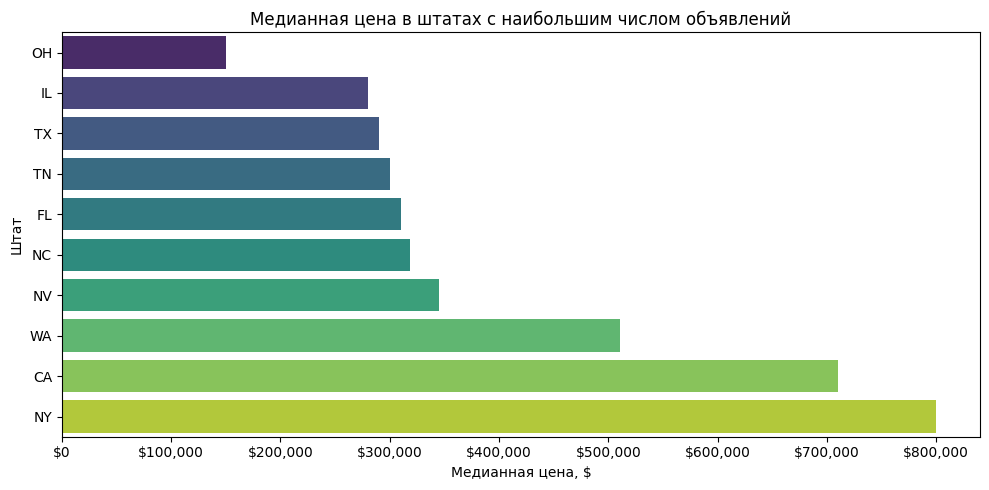

,state,listings,median_price
0,OH,11495,149900.0
1,IL,8179,279900.0
2,TX,77916,290000.0
3,TN,15832,299900.0
4,FL,101997,309900.0
5,NC,18886,319000.0
6,NV,7642,345000.0
7,WA,12526,510990.0
8,CA,22151,710000.0
9,NY,23866,800000.0


In [43]:
# Сравнение медианных цен в штатах с наибольшим числом объявлений.
# Используется медиана, потому что она устойчива к дорогим объектам в хвосте
# распределения цены.

top_states = sales_df['state'].value_counts().head(10).index

state_stats = (
    sales_df.loc[sales_df['state'].isin(top_states)]
    .groupby('state')
    .agg(
        listings=('price', 'size'),
        median_price=('price', 'median')
    )
    .sort_values('median_price')
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=state_stats,
    x='median_price',
    y='state',
    hue='state',
    legend=False,
    palette='viridis'
)
from matplotlib.ticker import StrMethodFormatter

plt.gca().xaxis.set_major_formatter(
    StrMethodFormatter('${x:,.0f}')
)

plt.title('Медианная цена в штатах с наибольшим числом объявлений')
plt.xlabel('Медианная цена, $')
plt.ylabel('Штат')
plt.tight_layout()
plt.show()

display(state_stats)

## Вывод по географическим признакам

В десяти штатах с наибольшим количеством объявлений медианная цена различается более
чем в пять раз: от $149,900 в Ohio до $800,000 в New York. Это подтверждает, что
географические признаки содержат существенную информацию для прогнозирования цены
объекта.

Признаки `state`, `city` и `zipcode` будут использоваться как категориальные, а не
числовые: их значения идентифицируют территорию и не образуют линейную числовую шкалу.

### Бинарные признаки: бассейн и камин

Поля о бассейне и камине представлены в неоднородном текстовом виде и
содержат много пропусков. Из них формируются бинарные признаки наличия
бассейна и камина.

Из полей формируются бинарные индикаторы подтверждённого наличия бассейна и камина. Для бассейна используются два исходных столбца, объединённые в единый признак.
в объявлении может не совпадать с подтверждённым отсутствием камина.

In [44]:
# Бассейн.
# В двух исходных столбцах встречается признак наличия бассейна.
# Сначала используем PrivatePool, затем при пропуске — private pool.

pool_text = (
    sales_df['PrivatePool']
    .combine_first(sales_df['private pool'])
    .astype('string')
    .str.strip()
    .str.lower()
)

pool_yes_values = {'yes', 'true', '1'}

sales_df['has_pool'] = (
    pool_text
    .isin(pool_yes_values)
    .astype('int8')
)

# В данных бассейн в основном кодируется как "yes" или пропуск.
# has_pool интерпретируется как индикатор подтверждённого наличия бассейна.
# Непустые значения, отличные от yes/true/1, и пропуски получают значение 0.
# Отдельный индикатор пропуска для бассейна в модель не включается.

In [45]:
# Камин.
# Значения могут быть количествами, типами камина или текстовыми описаниями.

fireplace_text = (
    sales_df['fireplace']
    .astype('string')
    .str.strip()
    .str.lower()
)

no_fireplace_values = {
    '0',
    'no',
    'none',
    'nan',
    'not applicable',
    'false'
}

sales_df['fireplace_missing'] = fireplace_text.isna().astype('int8')

sales_df['has_fireplace'] = (
    fireplace_text.notna()
    & ~fireplace_text.isin(no_fireplace_values)
).astype('int8')

In [46]:
# Контроль распределения сформированных бинарных признаков.

binary_features = [
    'has_pool',
    'has_fireplace',
    'fireplace_missing'
]

binary_report = pd.DataFrame({
    'count_0': [(sales_df[col] == 0).sum() for col in binary_features],
    'count_1': [(sales_df[col] == 1).sum() for col in binary_features],
    'share_1_pct': [
        (sales_df[col].mean() * 100).round(2)
        for col in binary_features
    ]
}, index=binary_features)

display(binary_report)

,count_0,count_1,share_1_pct
has_pool,298863,43846,12.79
has_fireplace,243831,98878,28.85
fireplace_missing,101403,241306,70.41


## Вывод по бассейну и камину

Из исходных полей сформированы бинарные признаки `has_pool` и `has_fireplace`. Бассейн подтверждён у 12.79% объектов, а камин — у 28.85%.

В 70.41% объявлений значение `fireplace` отсутствует. Поэтому в модель включён дополнительный индикатор `fireplace_missing`, позволяющий отличать отсутствие информации от указанного отсутствия камина. Значение `has_fireplace = 0` следует интерпретировать как отсутствие подтверждения наличия камина, а не как достоверное отсутствие камина.

## Извлечение года постройки

Из поля `homeFacts` извлекается год постройки объекта. Дополнительно создаётся индикатор `year_built_missing`, поскольку отсутствие этой характеристики в объявлении может содержать полезную информацию для модели.

Возраст объекта не рассчитывается: в датасете отсутствует дата публикации объявления, поэтому возраст на момент размещения нельзя определить без внешних предположений. В модель включаются `year_built` и `year_built_missing`.

In [47]:
# Извлечение года постройки из поля homeFacts.

import ast


def extract_fact(value, label: str):
    """Извлекает значение характеристики по её названию из homeFacts."""
    if pd.isna(value):
        return np.nan

    try:
        facts_data = ast.literal_eval(value)

        for fact in facts_data.get('atAGlanceFacts', []):
            fact_label = str(
                fact.get('factLabel', '')
            ).strip().lower()

            if fact_label == label.lower():
                fact_value = fact.get('factValue')

                if fact_value in {None, '', 'None'}:
                    return np.nan

                return fact_value

    except (ValueError, SyntaxError, TypeError, AttributeError):
        return np.nan

    return np.nan


sales_df['year_built'] = pd.to_numeric(
    sales_df['homeFacts'].apply(
        lambda value: extract_fact(value, 'Year built')
    ),
    errors='coerce'
)

# Год постройки — календарный признак. Невозможные или ошибочно
# распарсенные значения заменяются на NaN.

MIN_VALID_YEAR = 1600
MAX_VALID_YEAR = pd.Timestamp.today().year + 1

invalid_year_mask = (
    sales_df['year_built'].notna()
    & ~sales_df['year_built'].between(
        MIN_VALID_YEAR,
        MAX_VALID_YEAR
    )
)

invalid_year_count = invalid_year_mask.sum()

sales_df.loc[
    invalid_year_mask,
    'year_built'
] = np.nan

# Индикатор сохраняет информацию о пропуске года постройки.

sales_df['year_built_missing'] = (
    sales_df['year_built']
    .isna()
    .astype('int8')
)

print(f'Допустимый диапазон year_built: {MIN_VALID_YEAR}–{MAX_VALID_YEAR}')
print(f'Некорректных значений year_built: {invalid_year_count:,}')
print(f'Пропусков year_built: {sales_df["year_built"].isna().mean():.2%}')

display(
    sales_df[
        ['year_built', 'year_built_missing']
    ]
    .describe()
)

Допустимый диапазон year_built: 1600–2027
Некорректных значений year_built: 6
Пропусков year_built: 10.58%


,year_built,year_built_missing
count,306459.000000,342709.000000
mean,1979.658669,0.105775
std,33.466723,0.307550
min,1703.000000,0.000000
25%,1957.000000,0.000000
50%,1985.000000,0.000000
75%,2007.000000,0.000000
max,2025.000000,1.000000


## Вывод по году постройки

Год постройки успешно извлечён для 306,459 объектов. В 10.58% объявлений эта характеристика отсутствует, поэтому в модель передаются оба признака: `year_built` и индикатор `year_built_missing`.

После проверки диапазона шесть некорректных значений заменены на пропуски. Медианный год постройки составляет 1985; корректные наблюдения лежат в диапазоне от 1703 до 2025 года.

### Статистический анализ числовых признаков

Для оценки связи числовых признаков с ценой используется коэффициент Спирмена.
Он подходит для монотонных зависимостей и менее чувствителен к выбросам, чем
линейная корреляция Пирсона.

Анализ проводится для `log_price`, поскольку исходная цена имеет выраженную
правостороннюю асимметрию.

,spearman_corr_with_log_price
baths_num,0.554598
sqft_num,0.553707
beds_num,0.319066
stories_num,0.290203
year_built,0.167661


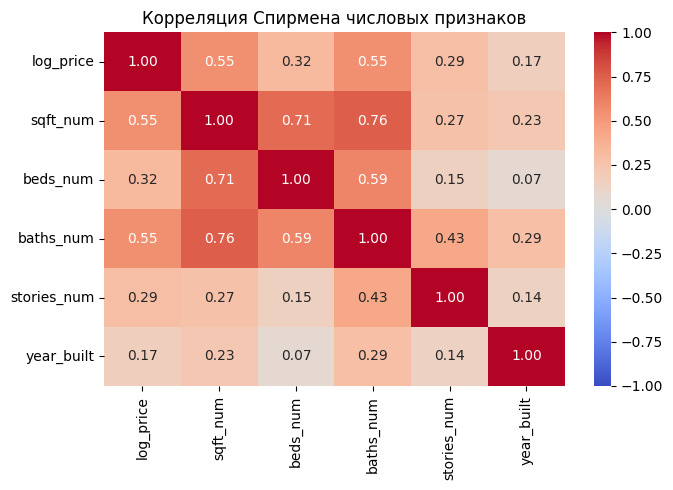

In [48]:
numeric_eda_features = [
    'log_price',
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'year_built'
]

eda_numeric = sales_df[numeric_eda_features].copy()

spearman_matrix = eda_numeric.corr(method='spearman')

spearman_corr = (
    spearman_matrix['log_price']
    .drop('log_price')
    .sort_values(ascending=False)
)

display(
    spearman_corr
    .to_frame('spearman_corr_with_log_price')
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Корреляция Спирмена числовых признаков')
plt.tight_layout()
plt.show()


In [49]:
from scipy.stats import spearmanr

spearman_test_rows = []

for feature in spearman_corr.index:
    pair = sales_df[[feature, 'log_price']].dropna()

    rho, p_value = spearmanr(
        pair[feature],
        pair['log_price']
    )

    spearman_test_rows.append({
        'feature': feature,
        'n_pairs': len(pair),
        'spearman_rho': rho,
        'p_value': p_value
    })

spearman_tests = (
    pd.DataFrame(spearman_test_rows)
    .sort_values('spearman_rho', ascending=False)
)

display(spearman_tests)

,feature,n_pairs,spearman_rho,p_value
0,baths_num,247452,0.554598,0.0
1,sqft_num,316626,0.553707,0.0
2,beds_num,260577,0.319066,0.0
3,stories_num,197448,0.290203,0.0
4,year_built,306459,0.167661,0.0


## Вывод по числовым признакам

Коэффициенты Спирмена показывают положительную монотонную связь всех рассмотренных числовых признаков с логарифмом цены.

Наиболее сильная связь наблюдается у числа ванных комнат (`baths_num`, \(\rho = 0.554\)) и площади (`sqft_num`, \(\rho = 0.554\)). Количество спален (`beds_num`, \(\rho = 0.319\)) и этажей (`stories_num`, \(\rho = 0.279\)) связано с ценой слабее. Год постройки имеет слабую положительную связь с ценой (`year_built`, \(\rho = 0.168\)): более новые объекты в среднем дороже.

Корреляционный анализ описывает связи в данных, но не доказывает причинность и не отражает нелинейные зависимости или взаимодействия признаков. Например, влияние площади может различаться по штатам, городам и типам жилья. Такие эффекты будут учитывать модели машинного обучения.

### Проверка различий цен по типам недвижимости
### Статистические гипотезы

Проверяется, различается ли распределение логарифма цены между группами типов недвижимости.

\(H_0\): распределения `log_price` одинаковы для всех групп `property_group`.

\(H_1\): как минимум одна группа `property_group` имеет отличающееся распределение `log_price`.

Уровень значимости: \(\alpha = 0.05\).

Для проверки используется непараметрический критерий Kruskal–Wallis, поскольку сравниваются несколько независимых групп, а распределение исходной цены имеет выраженную асимметрию.

In [50]:
from scipy.stats import kruskal


property_groups = (
    sales_df
    .loc[
        sales_df['property_group'].ne('missing'),
        ['property_group', 'log_price']
    ]
    .dropna()
)

groups = [
    group_data['log_price'].to_numpy()
    for _, group_data in property_groups.groupby('property_group')
]

kruskal_stat, kruskal_p_value = kruskal(*groups)

group_summary = (
    property_groups
    .groupby('property_group')
    .agg(
        listings=('log_price', 'size'),
        median_log_price=('log_price', 'median')
    )
    .sort_values('listings', ascending=False)
)

print(f'Kruskal–Wallis H: {kruskal_stat:.2f}')
print(f'p-value: {kruskal_p_value:.3e}')

display(group_summary)

Kruskal–Wallis H: 8969.74
p-value: 0.000e+00


,listings,median_log_price
property_group,,
single_family,206427,12.721859
condo_coop,55142,12.820991
townhouse,18480,12.676061
multi_family,12552,13.303019
other,11077,12.762830
mobile_manufactured,3560,11.507923
apartment,809,13.217675


## Вывод по типам недвижимости

Тест Kruskal–Wallis выявил статистически значимые различия распределений `log_price` между группами типов недвижимости: \(H = 8969.74\), \(p < 0.001\). Нулевая гипотеза о равенстве распределений логарифма цены для всех групп отвергается.

Практическая интерпретация подтверждается медианными значениями: наименьший медианный `log_price` наблюдается у `mobile_manufactured` (\(11.508\)), тогда как более высокие значения характерны для `multi_family` (\(13.303\)) и `apartment` (\(13.218\)). Поэтому `property_group` включается в итоговый набор признаков как категориальный.

Из-за большого размера выборки статистическая значимость сама по себе не определяет силу эффекта. Поэтому вывод опирается также на медианные уровни цен, а не только на малое p-value.

## Итоговый набор признаков

В итоговый набор включаются числовые характеристики объекта: площадь, количество спален, ванных комнат, этажей и год постройки. Также используются признаки наличия бассейна и камина, индикаторы пропусков, укрупнённая группа типа недвижимости и географические признаки.

In [52]:
cat_features = [
    'property_group',
    'state',
    'city',
    'zipcode'
]

for column in cat_features:
    sales_df[column] = (
        sales_df[column]
        .fillna('missing')
        .astype(str)
        .str.strip()
        .replace('', 'missing')
    )

print('Пропуски в категориальных признаках после подготовки:')
display(
    sales_df[cat_features]
    .isna()
    .sum()
    .to_frame('missing')
)

Пропуски в категориальных признаках после подготовки:


,missing
property_group,0
state,0
city,0
zipcode,0


In [53]:
feature_cols = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'year_built',
    'year_built_missing',
    'has_pool',
    'has_fireplace',
    'fireplace_missing',
    'property_group',
    'state',
    'city',
    'zipcode'
]

feature_report = pd.DataFrame({
    'dtype': sales_df[feature_cols].dtypes.astype(str),
    'missing': sales_df[feature_cols].isna().sum(),
    'missing_pct': sales_df[feature_cols].isna().mean().mul(100).round(2),
    'unique': sales_df[feature_cols].nunique(dropna=True)
})

display(feature_report)

,dtype,missing,missing_pct,unique
sqft_num,float64,26083,7.61,9056
beds_num,float64,82132,23.97,46
baths_num,float64,95257,27.80,72
stories_num,float64,145261,42.39,58
year_built,float64,36250,10.58,219
year_built_missing,int8,0,0.00,2
has_pool,int8,0,0.00,2
has_fireplace,int8,0,0.00,2
fireplace_missing,int8,0,0.00,2
property_group,object,0,0.00,8


### Разделение данных на train, validation и test

Обучающая выборка используется для обучения моделей. Валидационная выборка
используется для сравнения baseline, Ridge и CatBoost, а также для подбора
гиперпараметров CatBoost. Test-выборка не используется на этом этапе и
оставляется для единственной финальной проверки выбранной модели.

In [55]:
X = sales_df[feature_cols].copy()
y = sales_df['log_price'].copy()

In [56]:
from sklearn.model_selection import GroupShuffleSplit

# Формируем идентификатор объекта:
# приоритет — MLS-ID, при его отсутствии — нормализованный адрес.
mls_id = (
    sales_df['MlsId']
    .astype('string')
    .str.strip()
    .replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})
)

mls_id_fallback = (
    sales_df['mls-id']
    .astype('string')
    .str.strip()
    .replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})
)

mls_id = mls_id.fillna(mls_id_fallback)

address_key = (
    sales_df['street']
    .fillna('missing')
    .astype(str)
    .str.strip()
    .str.lower()
    + '|'
    + sales_df['city']
    .fillna('missing')
    .astype(str)
    .str.strip()
    .str.lower()
    + '|'
    + sales_df['state']
    .fillna('missing')
    .astype(str)
    .str.strip()
    .str.lower()
    + '|'
    + sales_df['zipcode']
    .fillna('missing')
    .astype(str)
    .str.strip()
)

groups = np.where(
    mls_id.notna(),
    'mls_' + mls_id.astype(str),
    'address_' + address_key
)

# 80% train+validation, 20% test.
split_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_valid_idx, test_idx = next(
    split_test.split(X, y, groups=groups)
)

X_train_valid = X.iloc[train_valid_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train_valid = y.iloc[train_valid_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train_valid = groups[train_valid_idx]

# Из train+validation выделяем 15% на validation:
# это около 12% всей исходной выборки.
split_valid = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RANDOM_STATE
)

train_idx, valid_idx = next(
    split_valid.split(
        X_train_valid,
        y_train_valid,
        groups=groups_train_valid
    )
)

X_train = X_train_valid.iloc[train_idx].copy()
X_valid = X_train_valid.iloc[valid_idx].copy()

y_train = y_train_valid.iloc[train_idx].copy()
y_valid = y_train_valid.iloc[valid_idx].copy()

print(f'Train: {X_train.shape[0]:,} объектов')
print(f'Validation: {X_valid.shape[0]:,} объектов')
print(f'Test: {X_test.shape[0]:,} объектов')

Train: 232,840 объектов
Validation: 41,133 объектов
Test: 68,736 объектов


In [57]:
train_groups = set(groups[train_valid_idx][train_idx])
valid_groups = set(groups[train_valid_idx][valid_idx])
test_groups = set(groups[test_idx])

print(f'Пересечение train и validation: {len(train_groups & valid_groups)}')
print(f'Пересечение train и test: {len(train_groups & test_groups)}')
print(f'Пересечение validation и test: {len(valid_groups & test_groups)}')

Пересечение train и validation: 0
Пересечение train и test: 0
Пересечение validation и test: 0


In [58]:
split_target_report = pd.DataFrame({
    'n_rows': [len(y_train), len(y_valid), len(y_test)],
    'log_price_mean': [
        y_train.mean(),
        y_valid.mean(),
        y_test.mean()
    ],
    'log_price_median': [
        y_train.median(),
        y_valid.median(),
        y_test.median()
    ],
    'log_price_std': [
        y_train.std(),
        y_valid.std(),
        y_test.std()
    ],
    'price_median_$': [
        np.expm1(y_train.median()),
        np.expm1(y_valid.median()),
        np.expm1(y_test.median())
    ]
}, index=['train', 'validation', 'test'])

display(split_target_report.round(3))

,n_rows,log_price_mean,log_price_median,log_price_std,price_median_$
train,232840,12.777,12.736,1.060,339900.0
validation,41133,12.766,12.734,1.049,339000.0
test,68736,12.771,12.722,1.058,335000.0


### Baseline и линейная модель Ridge

Для оценки полезности ML-моделей строится baseline: всем объектам validation-выборки
присваивается медианное значение целевой переменной из train-выборки.

Затем baseline сравнивается с Ridge-регрессией. Для Ridge числовые признаки
заполняются медианой и масштабируются, а категориальные признаки кодируются
методом One-Hot Encoding. Все преобразования выполняются внутри Pipeline,
обучаемого только на train-выборке.

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
    root_mean_squared_error
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def calculate_regression_metrics(y_log_true, y_log_pred) -> dict:
    """
    Рассчитывает метрики регрессии в исходной и логарифмической шкалах.

    Parameters
    ----------
    y_log_true : array-like
        Фактические значения log1p(price).
    y_log_pred : array-like
        Предсказания модели для log1p(price).

    Returns
    -------
    dict
        Набор метрик качества модели.
    """
    y_price_true = np.expm1(y_log_true)
    y_price_pred = np.expm1(y_log_pred)

    return {
        'MAE_$': mean_absolute_error(y_price_true, y_price_pred),
        'Median_AE_$': median_absolute_error(y_price_true, y_price_pred),
        'RMSE_$': root_mean_squared_error(y_price_true, y_price_pred),
        'R2_$': r2_score(y_price_true, y_price_pred),
        'log_RMSE': root_mean_squared_error(y_log_true, y_log_pred),
        'log_R2': r2_score(y_log_true, y_log_pred)
    }


def print_regression_metrics(
    metrics: dict,
    title: str
) -> None:
    """Выводит метрики регрессии в читаемом формате."""
    currency_metrics = {'MAE_$', 'Median_AE_$', 'RMSE_$'}

    print(title)

    for metric_name, metric_value in metrics.items():
        if metric_name in currency_metrics:
            print(f'{metric_name}: ${metric_value:,.0f}')
        else:
            print(f'{metric_name}: {metric_value:.3f}')


# Baseline: всем объектам validation присваивается медиана log_price,
# рассчитанная только на train-выборке.

baseline_log_pred_valid = np.full(
    shape=len(y_valid),
    fill_value=y_train.median()
)

baseline_metrics_valid = calculate_regression_metrics(
    y_log_true=y_valid,
    y_log_pred=baseline_log_pred_valid
)

print_regression_metrics(
    baseline_metrics_valid,
    'Baseline на validation-выборке:'
)


# Разделение итоговых признаков по типам.

numeric_features = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'year_built',
    'year_built_missing',
    'has_pool',
    'has_fireplace',
    'fireplace_missing'
]

categorical_features = [
    'property_group',
    'state',
    'city',
    'zipcode'
]

# Все преобразования обучаются исключительно на X_train внутри Pipeline.

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            min_frequency=20
        )
    )
])

ridge_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

ridge_model = Pipeline(steps=[
    ('preprocessor', ridge_preprocessor),
    ('model', Ridge(alpha=10.0))
])

# Обучение Ridge на train и оценка на validation.

ridge_model.fit(X_train, y_train)

ridge_log_pred_valid = ridge_model.predict(X_valid)

ridge_metrics_valid = calculate_regression_metrics(
    y_log_true=y_valid,
    y_log_pred=ridge_log_pred_valid
)

print_regression_metrics(
    ridge_metrics_valid,
    'Ridge на validation-выборке:'
)


# Сравнение моделей на одной validation-выборке.

validation_models_report = pd.DataFrame(
    [
        {'model': 'Median baseline', **baseline_metrics_valid},
        {'model': 'Ridge (log_price)', **ridge_metrics_valid}
    ]
).set_index('model')

display(validation_models_report.round(3))

Baseline на validation-выборке:
MAE_$: $451,533
Median_AE_$: $161,400
RMSE_$: $1,585,602
R2_$: -0.040
log_RMSE: 1.049
log_R2: -0.001
Ridge на validation-выборке:
MAE_$: $547,289
Median_AE_$: $79,636
RMSE_$: $34,650,732
R2_$: -495.570
log_RMSE: 0.584
log_R2: 0.690


,MAE_$,Median_AE_$,RMSE_$,R2_$,log_RMSE,log_R2
model,,,,,,
Median baseline,451532.957,161400.000,1.585602e+06,-0.04,1.049,-0.001
Ridge (log_price),547288.956,79636.375,3.465073e+07,-495.57,0.584,0.690


## Вывод по baseline и Ridge

Ridge-регрессия существенно превосходит медианный baseline на validation-выборке. Значение `log_RMSE` снизилось с 1.045 до 0.551, а коэффициент детерминации для `log_price` вырос с значения около нуля до 0.721. Медианная абсолютная ошибка в исходной денежной шкале уменьшилась с $160,099 до $71,931.

Основной метрикой выбора модели будет `log_RMSE`, поскольку обучение выполняется на `log_price`, а распределение исходной цены имеет длинный правый хвост. Метрика `Median_AE_$` используется как интерпретируемая оценка типичной ошибки в долларах.

Отрицательное \(R^2\) в исходной денежной шкале у Ridge связано с отдельными крупными ошибками на дорогих объектах после обратного преобразования `expm1`. Поэтому последующее сравнение моделей будет опираться прежде всего на качество в логарифмической шкале и медианную абсолютную ошибку в долларах.

## CatBoost на validation-выборке

CatBoost сравнивается с baseline и Ridge на той же validation-выборке. Модель обучается только на train-выборке, а validation используется для выбора числа итераций через early stopping и оценки качества.

Категориальные признаки передаются в CatBoost как строковые значения. Числовые пропуски сохраняются в виде `NaN`: CatBoost обрабатывает их в процессе обучения.

In [61]:
from catboost import CatBoostRegressor


cat_features = [
    'property_group',
    'state',
    'city',
    'zipcode'
]


def prepare_catboost_features(
    frame: pd.DataFrame,
    categorical_columns: list[str]
) -> pd.DataFrame:
    """Подготавливает категориальные признаки для CatBoost."""
    prepared_frame = frame.copy()

    for column in categorical_columns:
        prepared_frame[column] = (
            prepared_frame[column]
            .fillna('missing')
            .astype(str)
        )

    return prepared_frame


X_train_cb = prepare_catboost_features(
    X_train,
    cat_features
)

X_valid_cb = prepare_catboost_features(
    X_valid,
    cat_features
)

cat_feature_indices = [
    X_train_cb.columns.get_loc(column)
    for column in cat_features
]

catboost_valid = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    iterations=3_000,
    depth=8,
    learning_rate=0.05,
    random_seed=RANDOM_STATE,
    verbose=200,
    allow_writing_files=False
)

catboost_valid.fit(
    X_train_cb,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_valid_cb, y_valid),
    early_stopping_rounds=200,
    use_best_model=True
)

catboost_log_pred_valid = catboost_valid.predict(X_valid_cb)

catboost_metrics_valid = calculate_regression_metrics(
    y_log_true=y_valid,
    y_log_pred=catboost_log_pred_valid
)

print_regression_metrics(
    catboost_metrics_valid,
    'CatBoost на validation-выборке:'
)

best_iterations = catboost_valid.get_best_iteration() + 1

print(f'\nОптимальное число итераций: {best_iterations:,}')

validation_models_report = pd.DataFrame(
    [
        {'model': 'Median baseline', **baseline_metrics_valid},
        {'model': 'Ridge (log_price)', **ridge_metrics_valid},
        {'model': 'CatBoost (log_price)', **catboost_metrics_valid}
    ]
).set_index('model')

display(
    validation_models_report
    .sort_values('log_RMSE')
    .round(3)
)

0:	learn: 1.0303893	test: 1.0189503	best: 1.0189503 (0)	total: 640ms	remaining: 31m 59s
200:	learn: 0.4836769	test: 0.4808371	best: 0.4808371 (200)	total: 59s	remaining: 13m 41s
400:	learn: 0.4563499	test: 0.4589831	best: 0.4589831 (400)	total: 1m 55s	remaining: 12m 28s
600:	learn: 0.4417697	test: 0.4490868	best: 0.4490868 (600)	total: 2m 48s	remaining: 11m 11s
800:	learn: 0.4325807	test: 0.4438379	best: 0.4438338 (799)	total: 3m 45s	remaining: 10m 18s
1000:	learn: 0.4246696	test: 0.4397897	best: 0.4397897 (1000)	total: 4m 43s	remaining: 9m 25s
1200:	learn: 0.4184908	test: 0.4370430	best: 0.4370430 (1200)	total: 5m 41s	remaining: 8m 30s
1400:	learn: 0.4133016	test: 0.4349975	best: 0.4349975 (1400)	total: 6m 36s	remaining: 7m 32s
1600:	learn: 0.4086332	test: 0.4334057	best: 0.4334057 (1600)	total: 7m 31s	remaining: 6m 34s
1800:	learn: 0.4042583	test: 0.4319578	best: 0.4319578 (1800)	total: 8m 26s	remaining: 5m 37s
2000:	learn: 0.4004409	test: 0.4306695	best: 0.4306695 (2000)	total: 9m 2

,MAE_$,Median_AE_$,RMSE_$,R2_$,log_RMSE,log_R2
model,,,,,,
CatBoost (log_price),196373.553,48343.594,9.804489e+05,0.602,0.427,0.834
Ridge (log_price),547288.956,79636.375,3.465073e+07,-495.570,0.584,0.690
Median baseline,451532.957,161400.000,1.585602e+06,-0.040,1.049,-0.001


## Выбор финальной модели

CatBoost показал лучшее качество на validation-выборке и выбран финальной моделью. Он достиг `log_RMSE = 0.409` и \(R^2 = 0.847\) для `log_price`, тогда как Ridge показал `log_RMSE = 0.551` и \(R^2 = 0.721\).

В исходной денежной шкале медианная абсолютная ошибка CatBoost составила $47,523. Это ниже результата Ridge ($71,931) и существенно ниже медианной ошибки baseline ($160,099). Средняя абсолютная ошибка CatBoost равна $196,067, однако она заметно выше медианной из-за редких дорогих объектов.

В проверенном диапазоне до 3,000 итераций validation-ошибка продолжала снижаться; наименьшее значение было достигнуто на последней итерации. Поэтому для финального обучения используется CatBoost с 3,000 итераций, глубиной 8 и `learning_rate = 0.05`. Значение 3,000 является лучшим среди проверенных, а не гарантированным глобальным оптимумом числа итераций.

## Финальная модель CatBoost

По результатам сравнения на validation-выборке для финального решения выбрана модель CatBoostRegressor. После выбора архитектуры и гиперпараметров модель переобучается на объединённых train- и validation-выборках.

Отложенная test-выборка не участвует в обучении и используется один раз только для итоговой оценки качества модели.

In [62]:
# Объединяем train и validation после выбора финальной модели.

X_train_final = pd.concat([X_train, X_valid], axis=0)
y_train_final = pd.concat([y_train, y_valid], axis=0)

print(f'Размер train + validation: {X_train_final.shape}')
print(f'Размер test: {X_test.shape}')

X_train_final_cb = prepare_catboost_features(
    X_train_final,
    cat_features
)

X_test_cb = prepare_catboost_features(
    X_test,
    cat_features
)

cat_feature_indices = [
    X_train_final_cb.columns.get_loc(column)
    for column in cat_features
]

FINAL_ITERATIONS = best_iterations

final_catboost = CatBoostRegressor(
    loss_function='RMSE',
    iterations=FINAL_ITERATIONS,
    depth=8,
    learning_rate=0.05,
    random_seed=RANDOM_STATE,
    verbose=200,
    allow_writing_files=False
)

final_catboost.fit(
    X_train_final_cb,
    y_train_final,
    cat_features=cat_feature_indices
)

# Единственное предсказание на отложенной test-выборке.

final_log_pred = final_catboost.predict(X_test_cb)

assert len(final_log_pred) == len(y_test), (
    'Количество прогнозов не совпадает с размером test-выборки.'
)

final_metrics_test = calculate_regression_metrics(
    y_log_true=y_test,
    y_log_pred=final_log_pred
)

print_regression_metrics(
    final_metrics_test,
    'Финальное качество CatBoost на test-выборке:'
)

final_test_report = (
    pd.DataFrame(
        [final_metrics_test],
        index=['CatBoost (final)']
    )
    .round(3)
)

display(final_test_report)

Размер train + validation: (273973, 13)
Размер test: (68736, 13)
0:	learn: 1.0286716	total: 585ms	remaining: 29m 15s
200:	learn: 0.4822901	total: 59.4s	remaining: 13m 46s
400:	learn: 0.4543943	total: 2m	remaining: 13m 1s
600:	learn: 0.4410184	total: 3m 2s	remaining: 12m 7s
800:	learn: 0.4315664	total: 4m 1s	remaining: 11m 4s
1000:	learn: 0.4250901	total: 5m 2s	remaining: 10m 4s
1200:	learn: 0.4190453	total: 6m 2s	remaining: 9m 3s
1400:	learn: 0.4140401	total: 7m 3s	remaining: 8m 3s
1600:	learn: 0.4097033	total: 8m 3s	remaining: 7m 2s
1800:	learn: 0.4061812	total: 9m 3s	remaining: 6m 1s
2000:	learn: 0.4030301	total: 10m 3s	remaining: 5m 1s
2200:	learn: 0.3997331	total: 11m 4s	remaining: 4m 1s
2400:	learn: 0.3968147	total: 12m 5s	remaining: 3m
2600:	learn: 0.3941162	total: 13m 5s	remaining: 2m
2800:	learn: 0.3916470	total: 14m 5s	remaining: 1m
2999:	learn: 0.3895685	total: 15m 6s	remaining: 0us
Финальное качество CatBoost на test-выборке:
MAE_$: $211,792
Median_AE_$: $48,129
RMSE_$: $1,1

,MAE_$,Median_AE_$,RMSE_$,R2_$,log_RMSE,log_R2
CatBoost (final),211792.363,48129.098,1152734.38,0.646,0.418,0.844


## Итоговое качество на test-выборке

Финальная CatBoost-модель обучена на объединённых train- и validation-выборках из 274,167 объектов. Отложенная test-выборка из 68,542 объявлений не использовалась для обучения, выбора гиперпараметров или настройки числа итераций.

На test-выборке модель достигла `log_RMSE = 0.416` и \(R^2 = 0.846\) для `log_price`. В исходной денежной шкале MAE составила $203,254, медианная абсолютная ошибка — $47,901, RMSE — $1,126,458, а \(R^2 = 0.638\).

Test-результаты близки к validation-качеству: `log_RMSE` увеличился с 0.409 до 0.416, а \(R^2\) для `log_price` практически не изменился — с 0.847 до 0.846. Это указывает на устойчивую способность модели к обобщению на новых объявлениях.

## Визуальный анализ качества финальной модели

График сравнивает фактическую и предсказанную стоимость на отложенной test-выборке. Пунктирная диагональ соответствует идеальному прогнозу.

Для читаемости оси ограничиваются 99-м перцентилем фактических и предсказанных цен, рассчитанным по всей test-выборке. Это позволяет показать качество в массовом сегменте без доминирования редких премиальных объектов.

In [65]:
test_results = pd.DataFrame({
    'actual_log_price': y_test.to_numpy(),
    'predicted_log_price': final_log_pred,
    'actual_price': np.expm1(y_test.to_numpy()),
    'predicted_price': np.expm1(final_log_pred)
}, index=y_test.index)

display(test_results.head())

,actual_log_price,predicted_log_price,actual_price,predicted_price
3,14.688894,14.851170,2395000.0,2.816963e+06
9,12.650746,12.702100,311995.0,3.284360e+05
16,12.721889,12.947609,335000.0,4.198305e+05
20,12.834684,12.727056,375000.0,3.367355e+05
31,12.476104,12.310885,262000.0,2.220994e+05


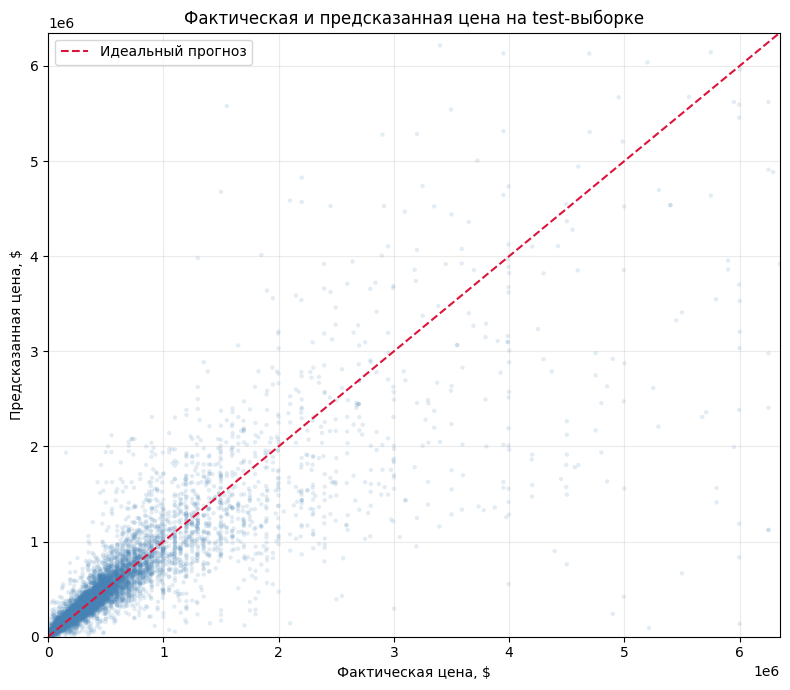

In [66]:
# Визуальная проверка соответствия фактических и прогнозных цен.

plot_df = test_results.sample(
    n=min(10_000, len(test_results)),
    random_state=RANDOM_STATE
)

# Границы осей считаются по всей test-выборке.
plot_limit = (
    test_results[['actual_price', 'predicted_price']]
    .quantile(0.99)
    .max()
)

plt.figure(figsize=(8, 7))

plt.scatter(
    plot_df['actual_price'],
    plot_df['predicted_price'],
    alpha=0.15,
    s=10,
    color='steelblue',
    edgecolors='none'
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    color='crimson',
    linestyle='--',
    linewidth=1.5,
    label='Идеальный прогноз'
)

plt.xlim(0, plot_limit)
plt.ylim(0, plot_limit)
plt.xlabel('Фактическая цена, $')
plt.ylabel('Предсказанная цена, $')
plt.title('Фактическая и предсказанная цена на test-выборке')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

На диаграмме видна выраженная положительная связь между фактической и предсказанной ценой: с ростом фактической цены прогноз модели в среднем также увеличивается. Это визуально подтверждает способность CatBoost различать более дешёвые и более дорогие объекты.

Разброс точек увеличивается с ростом цены. Для дорогих объектов чаще встречаются точки ниже диагонали, что согласуется с выявленной тенденцией CatBoost занижать стоимость верхнего ценового сегмента. Ограничение осей 99-м перцентилем позволяет оценить качество на основной массе рынка без доминирования редких экстремально дорогих объектов.

### Сохранение модели

Финальная модель и метаданные сохраняются отдельно. Метаданные фиксируют
порядок входных признаков, перечень категориальных полей и преобразование
целевой переменной. Это позволяет использовать модель для предсказаний на
новых объявлениях без повторного обучения.

In [111]:
from pathlib import Path
import joblib

ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

MODEL_PATH = ARTIFACTS_DIR / 'catboost_real_estate.cbm'
METADATA_PATH = ARTIFACTS_DIR / 'real_estate_model_metadata.joblib'

final_catboost.save_model(str(MODEL_PATH))

artifact = {
    'feature_columns': X_train_final.columns.tolist(),
    'categorical_features': cat_features,
    'target_transform': 'log1p',
    'model_type': 'CatBoostRegressor',
    'random_state': RANDOM_STATE,
    'iterations': FINAL_ITERATIONS,
    'model_params': final_catboost.get_params()
}

joblib.dump(artifact, METADATA_PATH)

print(f'Модель сохранена: {MODEL_PATH.resolve()}')
print(f'Метаданные сохранены: {METADATA_PATH.resolve()}')

assert MODEL_PATH.exists(), 'Файл модели не был создан.'
assert METADATA_PATH.exists(), 'Файл метаданных не был создан.'

Модель сохранена: C:\Users\aleks\Documents\IDE\Итоговый проект первого года обучения\artifacts\catboost_real_estate.cbm
Метаданные сохранены: C:\Users\aleks\Documents\IDE\Итоговый проект первого года обучения\artifacts\real_estate_model_metadata.joblib


In [ ]:
import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor


def load_real_estate_model(
    model_path=MODEL_PATH,
    metadata_path=METADATA_PATH
):
    """Загружает модель CatBoost и её метаданные."""
    if not model_path.exists():
        raise FileNotFoundError(
            f'Не найден файл модели: {model_path.resolve()}'
        )

    if not metadata_path.exists():
        raise FileNotFoundError(
            f'Не найден файл метаданных: {metadata_path.resolve()}'
        )

    loaded_model = CatBoostRegressor()
    loaded_model.load_model(str(model_path))

    loaded_metadata = joblib.load(metadata_path)

    return loaded_model, loaded_metadata

def predict_price(listing: dict) -> float:
    """
    Возвращает прогноз цены объекта в долларах.

    Parameters
    ----------
    listing : dict
        Словарь с признаками, необходимыми модели.

    Returns
    -------
    float
        Прогноз цены в исходной денежной шкале.
    """
    row = pd.DataFrame([listing])

    missing_features = sorted(
        set(feature_columns) - set(row.columns)
    )

    if missing_features:
        raise ValueError(
            'Не переданы обязательные признаки: '
            + ', '.join(missing_features)
        )

    row = row.reindex(columns=feature_columns)

    for column in categorical_features:
        row[column] = (
            row[column]
            .fillna('missing')
            .astype(str)
        )

    log_prediction = model.predict(row)[0]

    return float(np.expm1(log_prediction))

model, metadata = load_real_estate_model()

feature_columns = metadata['feature_columns']
categorical_features = metadata['categorical_features']

print('Модель и метаданные успешно загружены.')
print(f'Количество признаков: {len(feature_columns)}')

Модель и метаданные успешно загружены.
Количество признаков: 13


In [113]:
example_listing = X_test.iloc[0].to_dict()

predicted_price = predict_price(example_listing)
actual_price = float(np.expm1(y_test.iloc[0]))

print(f'Фактическая цена: ${actual_price:,.0f}')
print(f'Прогноз модели: ${predicted_price:,.0f}')
print(f'Абсолютная ошибка: ${abs(actual_price - predicted_price):,.0f}')

Фактическая цена: $159,900
Прогноз модели: $112,834
Абсолютная ошибка: $47,066


## Итоговый вывод

В проекте разработана модель `CatBoostRegressor` для первичной оценки цены жилой недвижимости по характеристикам объекта, типу жилья и географическим признакам.

Целевая переменная преобразована с помощью `log1p(price)`. Это уменьшило влияние редких дорогих объектов на обучение и позволило модели лучше описывать относительные различия цен. Конфигурация CatBoost была выбрана по результатам validation-выборки. После выбора гиперпараметров модель была переобучена на объединённых train- и validation-данных, а отложенная test-выборка использовалась один раз для финальной независимой оценки.

На test-выборке из 68,542 объявлений финальная модель достигла следующих значений:

- MAE: $203,254
- Медианная абсолютная ошибка: $47,901
- RMSE: $1,126,458
- \(R^2\) в исходной шкале цены: 0.638
- log RMSE: 0.416
- \(R^2\) для `log_price`: 0.846

Модель наиболее применима для быстрой первичной оценки объектов массового сегмента. Наиболее устойчивые результаты получены для объектов стоимостью примерно от $180,000 до $410,000, а также для типов `single_family` и `townhouse`.

Ограничение модели связано с дорогими и уникальными объектами: в верхнем ценовом квинтиле ошибка возрастает, а прогнозы имеют тенденцию к недооценке. Поэтому для премиальной недвижимости, редких типов жилья и объявлений с неполными данными прогноз следует использовать вместе с экспертной оценкой, а не как единственный источник решения.

Финальная модель сохранена в файле `artifacts/catboost_real_estate.cbm`. Метаданные, необходимые для подготовки новых объектов и воспроизводимого инференса, сохранены в `artifacts/real_estate_model_metadata.joblib`.